In [1]:
import numpy as np
import pandas as pd
import antropy as ant
import os
import h5py
import glob

from scipy.stats import skew, kurtosis
from vmdpy import VMD
from scipy.signal import butter, sosfiltfilt, iirnotch, filtfilt


In [5]:
DATASET_DIR = "/home/razzannr/Documents/GitHub/Python-notes/Skripsi/eeg_data" # direktori file mat
FS = 128 # sampling rate dataset
WINDOW_SEC = 5 # panjang window
POINTS_PER_WINDOW = FS * WINDOW_SEC   # 640

BIS_SADAR = 85 # batas atas
BIS_TIDAK_SADAR = 65 # batas bawah

RANGE_THR = 5.0
STD_THR = 2.0
MAXABS_THR = 1.0

In [ ]:
def load_case_mat(filepath):
    with h5py.File(filepath, "r") as f:
        keys = list(f.keys())
        print(f"\nFile: {os.path.basename(filepath)}")
        print("Keys tersedia:", keys)

        eeg_key = None
        bis_key = None

        for k in ["EEG", "eeg"]:
            if k in keys:
                eeg_key = k
                break

        for k in ["BIS", "bis"]:
            if k in keys:
                bis_key = k
                break

        if eeg_key is None or bis_key is None:
            print(
                f"[SKIP] Key EEG/BIS tidak ditemukan pada {os.path.basename(filepath)}. Keys: {keys}"
            )
            return None, None

        eeg = np.array(f[eeg_key]).squeeze().astype(float)
        bis = np.array(f[bis_key]).squeeze().astype(float)

    return eeg, bis

def process_case_to_clean_segments_5s(filepath):
    raw_eeg, raw_bis = load_case_mat(filepath)
    if raw_eeg is None or raw_bis is None:
        return None

    n_seg_from_bis = len(raw_bis)
    n_seg_from_eeg = len(raw_eeg) // POINTS_PER_WINDOW
    n_seg = min(n_seg_from_bis, n_seg_from_eeg)

    if n_seg < 1:
        return None

    eeg_used = raw_eeg[:n_seg * POINTS_PER_WINDOW]
    segments = eeg_used.reshape(n_seg, POINTS_PER_WINDOW)

    bis = raw_bis[:n_seg]

    segments = segments - np.mean(segments, axis=1, keepdims=True)

    seg_range = np.max(segments, axis=1) - np.min(segments, axis=1)
    seg_std = np.std(segments, axis=1)
    seg_maxabs = np.max(np.abs(segments), axis=1)

    is_bis_valid = np.isfinite(bis) & (bis >= 0) & (bis <= 100)

    is_blank = (
        (seg_maxabs <= MAXABS_THR) |
        (seg_range < RANGE_THR) |
        (seg_std < STD_THR)
    )

    is_valid = is_bis_valid & (~is_blank)

    label = np.full(n_seg, np.nan)
    label[is_valid & (bis >= BIS_SADAR)] = 1
    label[is_valid & (bis <= BIS_TIDAK_SADAR)] = 0

    keep = is_valid & np.isfinite(label)

    result = {
        "segments": segments[keep],
        "bis": bis[keep],
        "label": label[keep].astype(int),
        "segment_index": np.arange(n_seg)[keep],
        "case_id": os.path.basename(filepath)
    }

    print(f"Total segmen asli    : {n_seg}")
    print(f"Segmen valid dipakai : {len(result['label'])}")

    if len(result["label"]) > 0:
        unique, counts = np.unique(result["label"], return_counts=True)
        print("Distribusi label     :", dict(zip(unique, counts)))

    return result

def apply_eeg_filter(data, fs=128, lowcut=0.5, highcut=45.0, notch_freq=50.0):
    # bandpass 0.5 - 45
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    sos = butter(4, [low, high], analog=False, btype='band', output='sos')
    filtered = sosfiltfilt(sos, data)
    
    # notch filter 50 Hz
    w0 = notch_freq / nyq
    q = 30.0  
    b_notch, a_notch = iirnotch(w0, q)

    filtered = filtfilt(b_notch, a_notch, filtered)
    
    return filtered

def normalize_window(signal):
    signal = np.asarray(signal, dtype=float).ravel()
    signal = signal - np.mean(signal)
    signal = signal / (np.std(signal) + 1e-8)
    return signal

def extract_features(signal, sf=128):
    signal = np.asarray(signal).ravel()

    # cek apakah window itu valid
    if len(signal) < sf or (not np.isfinite(np.std(signal))) or np.std(signal) < 1e-8:
        return None

    features = {}

    try:
        features["sample_entropy"] = float(ant.sample_entropy(signal))
    except:
        features["sample_entropy"] = np.nan

    try:
        features["spectral_entropy"] = float(
            ant.spectral_entropy(signal, sf=sf, method="welch", normalize=True)
        )
    except:
        features["spectral_entropy"] = np.nan

    try:
        features["skewness"] = float(skew(signal))
    except:
        features["skewness"] = np.nan

    try:
        features["kurtosis"] = float(kurtosis(signal))
    except:
        features["kurtosis"] = np.nan

    return features

def apply_vmd(signal, K=3):
    signal = np.asarray(signal).ravel()

    alpha = 100
    tau = 0.0
    DC = 0
    init = 1
    tol = 1e-7

    u, u_hat, omega = VMD(signal, alpha, tau, K, DC, init, tol)
    return u

def extract_vmd_features(signal, sf=128, K=3):
    signal = np.asarray(signal).ravel()

    if len(signal) < sf or (not np.isfinite(np.std(signal))) or np.std(signal) < 1e-8:
        return None

    try:
        # 1. filter dulu
        filtered = apply_eeg_filter(signal, fs=sf)

        # 2. normalisasi setelah filter, sebelum VMD
        filtered = normalize_window(filtered)

        # 3. VMD menerima sinyal yang sudah dinormalisasi
        modes = apply_vmd(filtered, K=K)

    except Exception:
        return None

    feature_dict = {}

    for i in range(K):
        mode_signal = modes[i]

        feats = extract_features(mode_signal, sf=sf)

        if feats is None:
            return None

        feature_dict[f"mode{i+1}_sample_entropy"] = feats["sample_entropy"]
        feature_dict[f"mode{i+1}_spectral_entropy"] = feats["spectral_entropy"]
        feature_dict[f"mode{i+1}_skewness"] = feats["skewness"]
        feature_dict[f"mode{i+1}_kurtosis"] = feats["kurtosis"]

    return feature_dict

def build_5s_vmd_rows_from_case(case, sf=128, K=3):
    rows = []

    segments = case["segments"]
    labels = case["label"]
    bis_vals = case["bis"]
    seg_indices = case["segment_index"]
    case_id = case["case_id"]

    for i in range(len(segments)):
        signal = segments[i]
        label = labels[i]
        bis_val = bis_vals[i]
        seg_idx = seg_indices[i]

        feats = extract_vmd_features(signal, sf=sf, K=K)
        if feats is None:
            continue

        if not np.all(np.isfinite(list(feats.values()))):
            continue

        row = {
            "case_id": case_id,
            "segment_index": int(seg_idx),
            "label": int(label),
            "bis": float(bis_val),
        }

        row.update(feats)
        rows.append(row)

    return rows


File: case1.mat
Keys tersedia: ['EEG', 'bis']


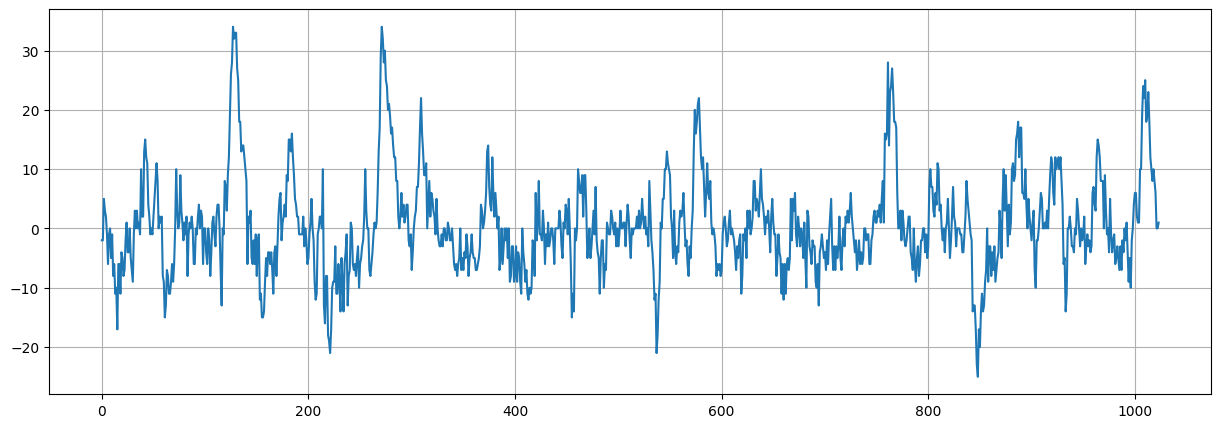

In [30]:
import matplotlib.pyplot as plt
import numpy as np

mat_files = sorted(glob.glob(os.path.join(DATASET_DIR, "*.mat")))

eeg, bis = load_case_mat(mat_files[0])

x = np.arange(0, 1024)
y = eeg[:1024]

plt.figure(figsize=(15,5))
plt.plot(x, y)
plt.grid(True)
plt.show()

In [11]:
mat_files = sorted(glob.glob(os.path.join(DATASET_DIR, "*.mat")))
print("Jumlah file .mat:", len(mat_files))

sample_case = process_case_to_clean_segments_5s(mat_files[0])

print("\nCase ID:", sample_case["case_id"])
print("Shape BIS:", sample_case["bis"].shape)
print("Shape label:", sample_case["label"].shape)
print("5 label pertama:", sample_case["label"][:5])
print("5 BIS pertama:", sample_case["bis"][:5])

Jumlah file .mat: 24

File: case1.mat
Keys tersedia: ['EEG', 'bis']
Total segmen asli    : 752
Segmen valid dipakai : 698
Distribusi label     : {np.int64(0): np.int64(667), np.int64(1): np.int64(31)}

Case ID: case1.mat
Shape BIS: (698,)
Shape label: (698,)
5 label pertama: [1 1 1 1 1]
5 BIS pertama: [98. 98. 98. 97. 97.]


In [5]:
all_cases_clean = []

for fp in mat_files:
    print("\n" + "=" * 60)
    case_result = process_case_to_clean_segments_5s(fp)

    if case_result is not None and len(case_result["label"]) > 0:
        all_cases_clean.append(case_result)

print("\nJumlah case yang berhasil dipakai:", len(all_cases_clean))



File: case1.mat
Keys tersedia: ['EEG', 'bis']
Total segmen asli    : 752
Segmen valid dipakai : 698
Distribusi label     : {np.int64(0): np.int64(667), np.int64(1): np.int64(31)}


File: case10.mat
Keys tersedia: ['EEG', 'bis']
Total segmen asli    : 1239
Segmen valid dipakai : 1138
Distribusi label     : {np.int64(0): np.int64(1072), np.int64(1): np.int64(66)}


File: case11.mat
Keys tersedia: ['EEG', 'bis']
Total segmen asli    : 2682
Segmen valid dipakai : 2509
Distribusi label     : {np.int64(0): np.int64(2417), np.int64(1): np.int64(92)}


File: case12.mat
Keys tersedia: ['EEG', 'bis']
Total segmen asli    : 4067
Segmen valid dipakai : 3948
Distribusi label     : {np.int64(0): np.int64(3901), np.int64(1): np.int64(47)}


File: case13.mat
Keys tersedia: ['EEG', 'bis']
Total segmen asli    : 818
Segmen valid dipakai : 803
Distribusi label     : {np.int64(0): np.int64(620), np.int64(1): np.int64(183)}


File: case14.mat
Keys tersedia: ['EEG', 'bis']
Total segmen asli    : 623
Segme

# ini untuk menguji waktu komputasi beberapa K

In [6]:
import time
import numpy as np
import pandas as pd

def benchmark_vmd_k(case_list, k_values=[2, 3, 4, 5], sf=128, max_segments_per_case=100):
    results = []

    for K in k_values:
        times = []
        valid_count = 0

        for case in case_list:
            segments = case["segments"]

            for i in range(min(len(segments), max_segments_per_case)):
                signal = segments[i]

                t0 = time.perf_counter()
                feats = extract_vmd_features(signal, sf=sf, K=K)
                t1 = time.perf_counter()

                if feats is not None and np.all(np.isfinite(list(feats.values()))):
                    times.append(t1 - t0)
                    valid_count += 1

        results.append({
            "K": K,
            "jumlah_fitur": K * 4,
            "window_valid": valid_count,
            "mean_time_sec": np.mean(times),
            "median_time_sec": np.median(times),
            "std_time_sec": np.std(times),
            "min_time_sec": np.min(times),
            "max_time_sec": np.max(times),
        })

        print(f"K={K} selesai | mean={np.mean(times):.4f}s | valid={valid_count}")

    return pd.DataFrame(results)

df_benchmark = benchmark_vmd_k(
    all_cases_clean[:5],
    k_values=[2, 3, 4, 5],
    sf=128,
    max_segments_per_case=100
)

df_benchmark

K=2 selesai | mean=0.0178s | valid=500
K=3 selesai | mean=0.0503s | valid=500
K=4 selesai | mean=0.0956s | valid=500
K=5 selesai | mean=0.1352s | valid=500


,K,jumlah_fitur,window_valid,mean_time_sec,median_time_sec,std_time_sec,min_time_sec,max_time_sec
0,2,8,500,0.017837,0.013527,0.014442,0.007236,0.087202
1,3,12,500,0.050315,0.040370,0.026327,0.016743,0.095626
2,4,16,500,0.095553,0.109114,0.031047,0.029567,0.144395
3,5,20,500,0.135176,0.148818,0.025592,0.045125,0.191698


In [6]:
all_rows_vmd = []

for case in all_cases_clean:
    rows = build_5s_vmd_rows_from_case(case, sf=128, K=3)
    print(f"{case['case_id']} -> {len(rows)} window")
    all_rows_vmd.extend(rows)

df_vmd = pd.DataFrame(all_rows_vmd)
print(df_vmd.shape)
df_vmd.head()

case1.mat -> 698 window
case10.mat -> 1138 window
case11.mat -> 2509 window
case12.mat -> 3948 window
case13.mat -> 803 window
case14.mat -> 573 window
case15.mat -> 2593 window
case16.mat -> 1320 window
case17.mat -> 1470 window
case18.mat -> 664 window
case19.mat -> 804 window
case2.mat -> 644 window
case20.mat -> 1813 window
case21.mat -> 1805 window
case22.mat -> 412 window
case23.mat -> 1100 window
case24.mat -> 713 window
case3.mat -> 2402 window
case4.mat -> 635 window
case5.mat -> 399 window
case6.mat -> 961 window
case7.mat -> 1114 window
case8.mat -> 1534 window
case9.mat -> 1139 window
(31191, 16)


,case_id,segment_index,label,bis,mode1_sample_entropy,mode1_spectral_entropy,mode1_skewness,mode1_kurtosis,mode2_sample_entropy,mode2_spectral_entropy,mode2_skewness,mode2_kurtosis,mode3_sample_entropy,mode3_spectral_entropy,mode3_skewness,mode3_kurtosis
0,case1.mat,0,1,98.0,0.356648,0.463058,1.325371,2.498423,0.676245,0.584957,0.082423,0.514858,1.407735,0.768263,-0.010104,0.446061
1,case1.mat,1,1,98.0,0.405171,0.482043,0.693704,2.123593,0.895702,0.686829,-0.076014,0.665598,1.497042,0.732619,-0.006410,-0.444490
2,case1.mat,2,1,98.0,0.263728,0.459516,1.675830,3.904920,0.739795,0.599923,0.153430,0.132940,1.525920,0.762684,-0.010113,0.417952
3,case1.mat,3,1,97.0,0.536415,0.550530,0.162999,0.670497,0.986915,0.699170,0.006934,0.284696,1.534261,0.726412,-0.027176,-0.454535
4,case1.mat,4,1,97.0,0.349225,0.482640,0.140373,0.604148,0.839062,0.640094,0.127741,0.873273,1.439011,0.745054,0.009203,0.617701


In [7]:
df_vmd = pd.DataFrame(all_rows_vmd)
df_vmd = df_vmd.replace([np.inf, -np.inf], np.nan)
df_vmd = df_vmd.dropna().reset_index(drop=True)

In [8]:
print("Shape akhir:", df_vmd.shape)
print(df_vmd["label"].value_counts())
print(df_vmd.head())

Shape akhir: (31191, 16)
label
0    29278
1     1913
Name: count, dtype: int64
     case_id  segment_index  label   bis  mode1_sample_entropy  \
0  case1.mat              0      1  98.0              0.356648   
1  case1.mat              1      1  98.0              0.405171   
2  case1.mat              2      1  98.0              0.263728   
3  case1.mat              3      1  97.0              0.536415   
4  case1.mat              4      1  97.0              0.349225   

   mode1_spectral_entropy  mode1_skewness  mode1_kurtosis  \
0                0.463058        1.325371        2.498423   
1                0.482043        0.693704        2.123593   
2                0.459516        1.675830        3.904920   
3                0.550530        0.162999        0.670497   
4                0.482640        0.140373        0.604148   

   mode2_sample_entropy  mode2_spectral_entropy  mode2_skewness  \
0              0.676245                0.584957        0.082423   
1              0.895702

In [9]:
df_vmd.to_csv("dataset_VMD_short_normal.csv", index=False)
print("CSV berhasil disimpan: dataset_15s_vmd_k3_features.csv")

CSV berhasil disimpan: dataset_15s_vmd_k3_features.csv


# semua di bawah ini untuk menguji seberapa akurasi masing masing K

In [6]:
import random

RANDOM_STATE = 42
N_CASE_SUBSET = 5

random.seed(RANDOM_STATE)

mat_files_subset = random.sample(mat_files, min(N_CASE_SUBSET, len(mat_files)))

print("File subset:")
for f in mat_files_subset:
    print(f)

File subset:
../eeg_data/case6.mat
../eeg_data/case12.mat
../eeg_data/case1.mat
../eeg_data/case9.mat
../eeg_data/case17.mat


In [7]:
all_cases_clean_subset = []

for fp in mat_files_subset:
    print("\n" + "=" * 60)
    case_result = process_case_to_clean_segments_5s(fp)

    if case_result is not None and len(case_result["label"]) > 0:
        all_cases_clean_subset.append(case_result)

print("Jumlah case subset:", len(all_cases_clean_subset))



File: case6.mat
Keys tersedia: ['EEG', 'bis']
Total segmen asli    : 1005
Segmen valid dipakai : 961
Distribusi label     : {np.int64(0): np.int64(901), np.int64(1): np.int64(60)}


File: case12.mat
Keys tersedia: ['EEG', 'bis']
Total segmen asli    : 4067
Segmen valid dipakai : 3948
Distribusi label     : {np.int64(0): np.int64(3901), np.int64(1): np.int64(47)}


File: case1.mat
Keys tersedia: ['EEG', 'bis']
Total segmen asli    : 752
Segmen valid dipakai : 698
Distribusi label     : {np.int64(0): np.int64(667), np.int64(1): np.int64(31)}


File: case9.mat
Keys tersedia: ['EEG', 'bis']
Total segmen asli    : 1195
Segmen valid dipakai : 1139
Distribusi label     : {np.int64(0): np.int64(897), np.int64(1): np.int64(242)}


File: case17.mat
Keys tersedia: ['EEG', 'bis']
Total segmen asli    : 1519
Segmen valid dipakai : 1470
Distribusi label     : {np.int64(0): np.int64(1389), np.int64(1): np.int64(81)}
Jumlah case subset: 5


In [8]:
import numpy as np

MAX_SEGMENTS_PER_CASE = 100
RANDOM_STATE = 42

def make_case_segment_subset(case, max_segments=100, random_state=42):
    rng = np.random.default_rng(random_state)

    n = len(case["segments"])
    n_take = min(max_segments, n)

    selected_idx = rng.choice(n, size=n_take, replace=False)
    selected_idx = np.sort(selected_idx)

    case_subset = {
        "segments": case["segments"][selected_idx],
        "label": case["label"][selected_idx],
        "bis": case["bis"][selected_idx],
        "segment_index": case["segment_index"][selected_idx],
        "case_id": case["case_id"]
    }

    return case_subset

all_cases_clean_trial = [
    make_case_segment_subset(case, MAX_SEGMENTS_PER_CASE, RANDOM_STATE)
    for case in all_cases_clean_subset
]

for case in all_cases_clean_trial:
    print(case["case_id"], len(case["label"]), np.bincount(case["label"]))

case6.mat 100 [98  2]
case12.mat 100 [100]
case1.mat 100 [99  1]
case9.mat 100 [82 18]
case17.mat 100 [99  1]


In [9]:
import pandas as pd
import time
import os

K_LIST = [2, 3, 4, 5]
OUTPUT_DIR = "./multiple_K"  # ubah sesuai foldermu
os.makedirs(OUTPUT_DIR, exist_ok=True)

summary_rows = []

for K in K_LIST:
    print("\n" + "=" * 70)
    print(f"Mulai ekstraksi dataset subset VMD K={K}")

    all_rows = []
    times = []

    for case in all_cases_clean_trial:
        rows_case = []

        for i in range(len(case["segments"])):
            signal = case["segments"][i]
            label = case["label"][i]
            bis_val = case["bis"][i]
            seg_idx = case["segment_index"][i]

            t0 = time.perf_counter()
            feats = extract_vmd_features(signal, sf=128, K=K)
            t1 = time.perf_counter()

            if feats is None:
                continue

            if not np.all(np.isfinite(list(feats.values()))):
                continue

            row = {
                "case_id": case["case_id"],
                "segment_index": int(seg_idx),
                "label": int(label),
                "bis": float(bis_val),
            }

            row.update(feats)
            rows_case.append(row)
            times.append(t1 - t0)

        print(f"{case['case_id']} -> {len(rows_case)} segmen valid")
        all_rows.extend(rows_case)

    df_k = pd.DataFrame(all_rows)
    df_k = df_k.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

    output_csv = os.path.join(OUTPUT_DIR, f"dataset_subset_VMD_K{K}.csv")
    df_k.to_csv(output_csv, index=False)

    print(f"CSV K={K} tersimpan:", output_csv)
    print("Shape:", df_k.shape)
    print(df_k["label"].value_counts())

    summary_rows.append({
        "K": K,
        "jumlah_fitur": K * 4,
        "jumlah_data": len(df_k),
        "mean_time_sec": np.mean(times),
        "median_time_sec": np.median(times),
        "std_time_sec": np.std(times),
        "min_time_sec": np.min(times),
        "max_time_sec": np.max(times),
        "csv_path": output_csv
    })

df_summary_k = pd.DataFrame(summary_rows)
df_summary_k


Mulai ekstraksi dataset subset VMD K=2
case6.mat -> 100 segmen valid
case12.mat -> 100 segmen valid
case1.mat -> 100 segmen valid
case9.mat -> 100 segmen valid
case17.mat -> 100 segmen valid
CSV K=2 tersimpan: ./multiple_K/dataset_subset_VMD_K2.csv
Shape: (500, 12)
label
0    478
1     22
Name: count, dtype: int64

Mulai ekstraksi dataset subset VMD K=3
case6.mat -> 100 segmen valid
case12.mat -> 100 segmen valid
case1.mat -> 100 segmen valid
case9.mat -> 100 segmen valid
case17.mat -> 100 segmen valid
CSV K=3 tersimpan: ./multiple_K/dataset_subset_VMD_K3.csv
Shape: (500, 16)
label
0    478
1     22
Name: count, dtype: int64

Mulai ekstraksi dataset subset VMD K=4
case6.mat -> 100 segmen valid
case12.mat -> 100 segmen valid
case1.mat -> 100 segmen valid
case9.mat -> 100 segmen valid
case17.mat -> 100 segmen valid
CSV K=4 tersimpan: ./multiple_K/dataset_subset_VMD_K4.csv
Shape: (500, 20)
label
0    478
1     22
Name: count, dtype: int64

Mulai ekstraksi dataset subset VMD K=5
case6.mat

,K,jumlah_fitur,jumlah_data,mean_time_sec,median_time_sec,std_time_sec,min_time_sec,max_time_sec,csv_path
0,2,8,500,0.027040,0.025302,0.011685,0.008451,0.070063,./multiple_K/dataset_subset_VMD_K2.csv
1,3,12,500,0.060552,0.056396,0.022162,0.016716,0.103756,./multiple_K/dataset_subset_VMD_K3.csv
2,4,16,500,0.110656,0.121584,0.022434,0.029791,0.154164,./multiple_K/dataset_subset_VMD_K4.csv
3,5,20,500,0.142871,0.148671,0.018112,0.055475,0.187034,./multiple_K/dataset_subset_VMD_K5.csv
